# I2 - Génération de contre-arguments par raisonnement formel



Quand on a un argument, comment trouver automatiquement les arguments qui le contredisent ? C'est
la question de départ de ce notebook.

On utilise ASPIC+ pour écrire des arguments structurés (avec des prémisses et des règles), puis
on génère leurs trois types de contre-arguments : undercut, rebut, undermine. 

À partir de là on construit le graphe de Dung correspondant, on calcule ses extensions avec quatre sémantiques
différentes, et on regarde quelles positions restent défendables. On finit par comparer
ASPIC+ à un framework abstrait classique pour voir ce qu'il apporte en plus.

Tout tourne avec TweetyProject (une librairie Java) qu'on pilote depuis Python grâce à
JPype : c'est elle qui fait les calculs et garantit qu'ils sont corrects.



#### Les 5 objectifs (validés tout au long du notebook)
1. Formaliser en ASPIC+ — règles strictes/défaisables, base avec axiomes/présomptions → **§1**
2. Générer automatiquement undercut / rebut / undermine depuis un argument cible → **§2**
3. Calculer les extensions de Dung (grounded, complete, preferred, stable) → **§3**
4. Évaluer la défendabilité des positions face aux contre-arguments → **§4**
5. Comparer la richesse ASPIC+ vs frameworks abstraits → **§5**


## 0. Configuration de l'environnement

TweetyProject est une bibliothèque **Java** : on démarre une JVM avec JPype en lui passant le JAR
`tweety-full` (modules `arg.aspic`, `arg.dung`, `logics.pl`, ...). La JVM ne démarre qu'une fois
par noyau, d'où la protection `isJVMStarted()`.


In [28]:
import os, glob
import jpype
import jpype.imports

if not os.environ.get("JAVA_HOME"):
    jdk = glob.glob(r"C:\Program Files\Eclipse Adoptium\jdk*")
    if jdk:
        os.environ["JAVA_HOME"] = jdk[0]

jar = glob.glob(os.path.join(os.getcwd(), "lib", "tweety-full-*-with-dependencies.jar"))[0]

if not jpype.isJVMStarted():
    jpype.startJVM(classpath=[jar])

print("JVM demarree :", jpype.isJVMStarted())
print("JAVA_HOME   :", os.environ["JAVA_HOME"])
print("JAR Tweety  :", os.path.basename(jar))

JVM demarree : True
JAVA_HOME   : C:\Program Files\Eclipse Adoptium\jdk-21.0.11.10-hotspot
JAR Tweety  : tweety-full-1.30-with-dependencies.jar


In [29]:
from org.tweetyproject.arg.aspic.syntax import (AspicArgumentationTheory,
                                                 DefeasibleInferenceRule,
                                                 StrictInferenceRule)
from org.tweetyproject.arg.aspic.ruleformulagenerator import PlFormulaGenerator
from org.tweetyproject.logics.pl.parser import PlParser
from org.tweetyproject.arg.dung.syntax import DungTheory, Argument, Attack
from org.tweetyproject.arg.dung.reasoner import (SimpleGroundedReasoner,
                                                 SimpleCompleteReasoner,
                                                 SimplePreferredReasoner,
                                                 SimpleStableReasoner)

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import networkx as nx
import pandas as pd
%matplotlib inline

print("Imports TweetyProject + visualisation OK.")

Imports TweetyProject + visualisation OK.


### Vue d'ensemble du raisonnement

Le schéma ci-dessous résume la chaîne de traitement, de la base de connaissances jusqu'à la
défendabilité des positions.


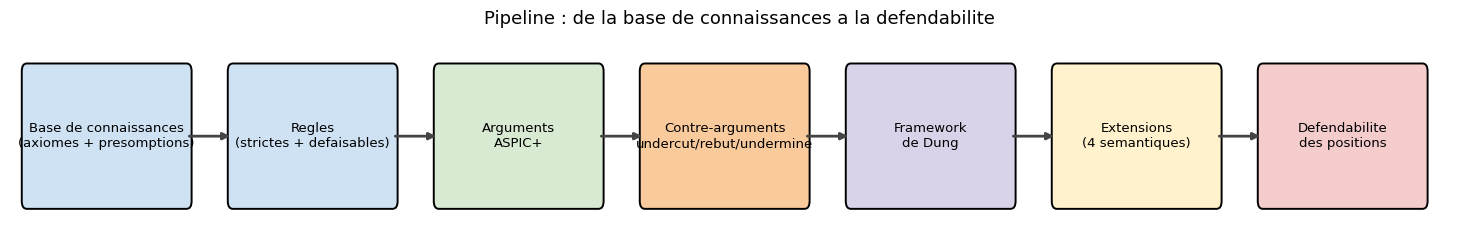

In [30]:
etapes = [
    "Base de connaissances\n(axiomes + presomptions)",
    "Regles\n(strictes + defaisables)",
    "Arguments\nASPIC+",
    "Contre-arguments\nundercut/rebut/undermine",
    "Framework\nde Dung",
    "Extensions\n(4 semantiques)",
    "Defendabilite\ndes positions",
]
couleurs_pipe = ["#cfe2f3", "#cfe2f3", "#d9ead3", "#f9cb9c", "#d9d2e9", "#fff2cc", "#f4cccc"]

fig, ax = plt.subplots(figsize=(15, 2.6))
x = 0.0
largeur, hauteur, ecart = 1.9, 1.0, 0.55
for i, (txt, col) in enumerate(zip(etapes, couleurs_pipe)):
    boite = FancyBboxPatch((x, 0), largeur, hauteur, boxstyle="round,pad=0.06",
                           linewidth=1.4, edgecolor="black", facecolor=col)
    ax.add_patch(boite)
    ax.text(x + largeur / 2, hauteur / 2, txt, ha="center", va="center", fontsize=9.5)
    if i < len(etapes) - 1:
        ax.annotate("", xy=(x + largeur + ecart, hauteur / 2),
                    xytext=(x + largeur, hauteur / 2),
                    arrowprops=dict(arrowstyle="-|>", lw=2, color="#444"))
    x += largeur + ecart
ax.set_xlim(-0.2, x); ax.set_ylim(-0.3, 1.3); ax.axis("off")
ax.set_title("Pipeline : de la base de connaissances a la defendabilite", fontsize=13)
plt.tight_layout(); plt.show()

## 1. Formalisation en ASPIC+

### 1.1 Rappel du formalisme

Une théorie ASPIC+ repose sur :

- une **base de connaissances** :
  - **axiomes** : prémisses certaines, *non attaquables* ;
  - **présomptions** (prémisses ordinaires) : prémisses plausibles, *attaquables* ;
- des **règles d'inférence** :
  - **règles strictes** `φ1,…,φn -> ψ` : inférences indiscutables ;
  - **règles défaisables** `φ1,…,φn => ψ` : inférences plausibles, *attaquables*.

Un **argument** chaîne prémisses et règles. Il est *strict/firm* s'il n'utilise que des axiomes et
des règles strictes.

### 1.2 Exemple support : la culpabilité d'un suspect

| symbole | signification | type |
|---|---|---|
| `adn` | l'ADN du suspect est sur les lieux | **axiome** |
| `t` | un témoin affirme avoir vu le suspect | présomption |
| `m` | le témoin est myope sans lunettes | présomption |
| `a` | le suspect dispose d'un alibi | présomption |
| `pr` | le témoignage a été recueilli sous pression | présomption |
| `labo` | doute sur la fiabilité du laboratoire ADN | présomption |
| `cam` | une caméra contredit l'alibi | présomption |

| règle | lecture | nature |
|---|---|---|
| `d1 : t => coupable` | le témoignage suggère la culpabilité | défaisable |
| `d2 : adn => coupable` | l'ADN suggère la culpabilité | défaisable |
| `d3 : m => ¬t` | myope ⇒ le témoin n'a pas vraiment vu | défaisable |
| `d4 : a => ¬coupable` | l'alibi ⇒ non coupable | défaisable |
| `d5 : pr => ¬d1` | sous pression ⇒ la règle `d1` ne s'applique pas | défaisable |
| `d6 : labo => ¬d2` | labo douteux ⇒ la règle `d2` ne s'applique pas | défaisable |
| `d7 : cam => ¬a` | caméra ⇒ l'alibi tombe | défaisable |
| `s1 : coupable -> punissable` | définition légale | **stricte** |


In [31]:
gen = PlFormulaGenerator()
theorie = AspicArgumentationTheory(gen)
theorie.setRuleFormulaGenerator(gen)
parser = PlParser()

def f(s):
    return parser.parseFormula(s)

theorie.addAxiom(f("adn"))
for p in ["t", "m", "a", "pr", "labo", "cam"]:
    theorie.addOrdinaryPremise(f(p))

def defeasible(nom, conclusion, premisse):
    r = DefeasibleInferenceRule()
    r.setName(nom); r.setConclusion(f(conclusion)); r.addPremise(f(premisse))
    theorie.addRule(r); return r

def stricte(nom, conclusion, premisse):
    r = StrictInferenceRule()
    r.setName(nom); r.setConclusion(f(conclusion)); r.addPremise(f(premisse))
    theorie.addRule(r); return r

d1 = defeasible("d1", "coupable", "t")
d2 = defeasible("d2", "coupable", "adn")
d3 = defeasible("d3", "!t", "m")
d4 = defeasible("d4", "!coupable", "a")
d5 = defeasible("d5", "!d1", "pr")
d6 = defeasible("d6", "!d2", "labo")
d7 = defeasible("d7", "!a", "cam")
s1 = stricte("s1", "punissable", "coupable")

print("Theorie ASPIC+ construite -- 1 axiome, 6 presomptions,",
      "7 regles defaisables, 1 regle stricte.")

Theorie ASPIC+ construite -- 1 axiome, 6 presomptions, 7 regles defaisables, 1 regle stricte.


### 1.3 Arguments engendrés

TweetyProject construit automatiquement tous les arguments dérivables. On leur donne un
identifiant court (A0, A1, …).


In [32]:
def contraire(formule):
    return formule.complement()

def meme(x, y):
    return x.equals(y)

arguments = list(theorie.getArguments())
arguments.sort(key=lambda a: str(a))
ids = {str(a): "A%d" % i for i, a in enumerate(arguments)}
def idof(a): return ids[str(a)]
par_nom = {str(a): a for a in arguments}
arg_par_id = {idof(a): a for a in arguments}

print("Nombre d'arguments :", len(arguments), "\n")
for a in arguments:
    nature = "firm/strict" if a.isStrict() else "defaisable "
    print("%-4s [%s]  conclusion = %-10s  |  %s" % (idof(a), nature, a.getConclusion(), a))

Nombre d'arguments : 16 

A0   [firm/strict]  conclusion = adn         |   -> adn
A1   [firm/strict]  conclusion = a           |   => a
A2   [firm/strict]  conclusion = cam         |   => cam
A3   [firm/strict]  conclusion = labo        |   => labo
A4   [firm/strict]  conclusion = m           |   => m
A5   [firm/strict]  conclusion = pr          |   => pr
A6   [firm/strict]  conclusion = t           |   => t
A7   [defaisable ]  conclusion = coupable    |  d1: t => coupable [ => t]
A8   [defaisable ]  conclusion = coupable    |  d2: adn => coupable [ -> adn]
A9   [defaisable ]  conclusion = !t          |  d3: m => !t [ => m]
A10  [defaisable ]  conclusion = !coupable   |  d4: a => !coupable [ => a]
A11  [defaisable ]  conclusion = !d1         |  d5: pr => !d1 [ => pr]
A12  [defaisable ]  conclusion = !d2         |  d6: labo => !d2 [ => labo]
A13  [defaisable ]  conclusion = !a          |  d7: cam => !a [ => cam]
A14  [defaisable ]  conclusion = punissable  |  s1: coupable -> punissable 

### 1.4 Structure interne d'un argument *(arbre de dérivation)*

Contrairement à un framework abstrait, un argument ASPIC+ a une structure : un arbre dont les
feuilles sont des prémisses (axiomes/présomptions) et les noeuds internes des applications de
règles. C'est précisément cette structure qui rendra possible la génération ciblée des
contre-arguments.

*Couleurs : bleu clair = axiome / vert = présomption / bleu foncé = règle stricte / orange = règle défaisable.*


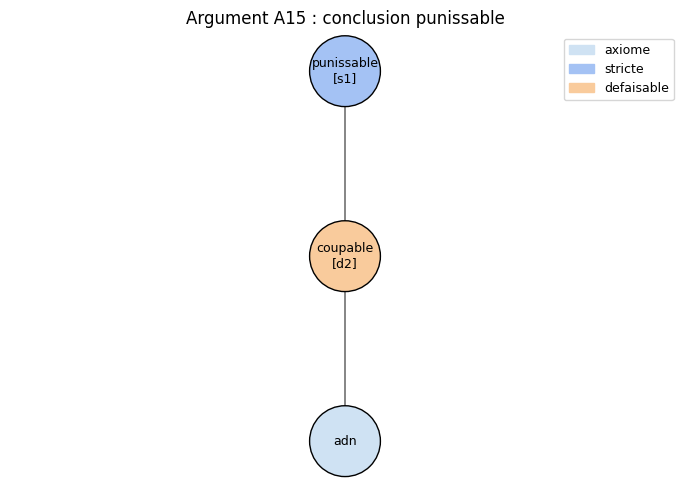

In [33]:
def nom_regle(sub):
    top = sub.getTopRule()
    if top is None:
        return None
    nm = top.getName()
    if nm is None or str(nm) in ("", "null"):
        return None
    return str(nm)

COUL_CAT = {"axiome": "#cfe2f3", "presomption": "#d9ead3",
            "stricte": "#a4c2f4", "defaisable": "#f9cb9c"}

AXIOMES = {"adn"}

def categorie(sub):
    if not list(sub.getDirectSubs()):
        return "axiome" if str(sub.getConclusion()) in AXIOMES else "presomption"
    top = sub.getTopRule()
    return "defaisable" if (top is not None and top.isDefeasible()) else "stricte"

def construire_arbre(racine):
    G = nx.DiGraph()
    labels = {}
    def rec(sub):
        nid = str(sub)
        r = nom_regle(sub)
        labels[nid] = str(sub.getConclusion()) + (("\n[" + r + "]") if r else "")
        G.add_node(nid, cat=categorie(sub))
        for d in sub.getDirectSubs():
            G.add_edge(nid, str(d)); rec(d)
    rec(racine)
    return G, labels

def positions_arbre(G, racine_id):
    prof = nx.single_source_shortest_path_length(G, racine_id)
    niveaux = {}
    for n, p in prof.items():
        niveaux.setdefault(p, []).append(n)
    pos = {}
    for p, ns in niveaux.items():
        for i, n in enumerate(sorted(ns)):
            pos[n] = (i - (len(ns) - 1) / 2.0, -p)
    return pos

def dessiner_arbre(racine, ax=None):
    seul = ax is None
    if seul:
        fig, ax = plt.subplots(figsize=(7, 5))
    G, labels = construire_arbre(racine)
    pos = positions_arbre(G, str(racine))
    cols = [COUL_CAT[G.nodes[n]["cat"]] for n in G.nodes]
    nx.draw_networkx_nodes(G, pos, node_color=cols, node_size=2600,
                           edgecolors="black", ax=ax)
    nx.draw_networkx_edges(G, pos, arrowstyle="-|>", arrowsize=18,
                           edge_color="#555", ax=ax)
    nx.draw_networkx_labels(G, pos, labels, font_size=9, ax=ax)
    presentes = set(G.nodes[n]["cat"] for n in G.nodes)
    h = [mpatches.Patch(color=COUL_CAT[k], label=k) for k in
         ["axiome", "presomption", "stricte", "defaisable"] if k in presentes]
    ax.legend(handles=h, loc="upper right", fontsize=9)
    ax.set_title("Argument %s : conclusion %s" % (idof(racine), racine.getConclusion()),
                 fontsize=12)
    ax.axis("off")
    if seul:
        plt.tight_layout(); plt.show()

arg_punissable = None
for a in arguments:
    if meme(a.getConclusion(), f("punissable")):
        noms = [str(r.getName()) for r in a.getAllRules()]
        if "d2" in noms:
            arg_punissable = a
dessiner_arbre(arg_punissable)

Cet argument empile une règle stricte (s1, en bleu foncé) au-dessus d'une règle
défaisable (d2, en orange) appliquée à l'axiome adn (en bleu clair). On voit
directement les points attaquables (la partie défaisable) et les points sûrs (la partie firm).

 ### 1.5 **Démo Live** - explorateur de structure
 on choisit n'importe quel argument : son arbre de dérivation s'affiche


In [34]:
from ipywidgets import interact, Dropdown, IntSlider

def explorer_structure(argument):
    dessiner_arbre(arg_par_id[argument])

interact(explorer_structure,
         argument=Dropdown(options=[idof(a) for a in arguments],
                           value=idof(arg_punissable), description="Argument"));

interactive(children=(Dropdown(description='Argument', index=15, options=('A0', 'A1', 'A2', 'A3', 'A4', 'A5', …

## 2. Génération automatique des contre-arguments

### 2.1 Les trois types d'attaque

Selon le point visé dans la structure de l'argument cible :

- **undermine** → une prémisse ordinaire (présomption) ;
- **rebut** → la conclusion d'une règle défaisable ;
- **undercut** → l'applicabilité d'une règle défaisable.

Le schéma ci-dessous localise les trois attaques sur un argument générique.


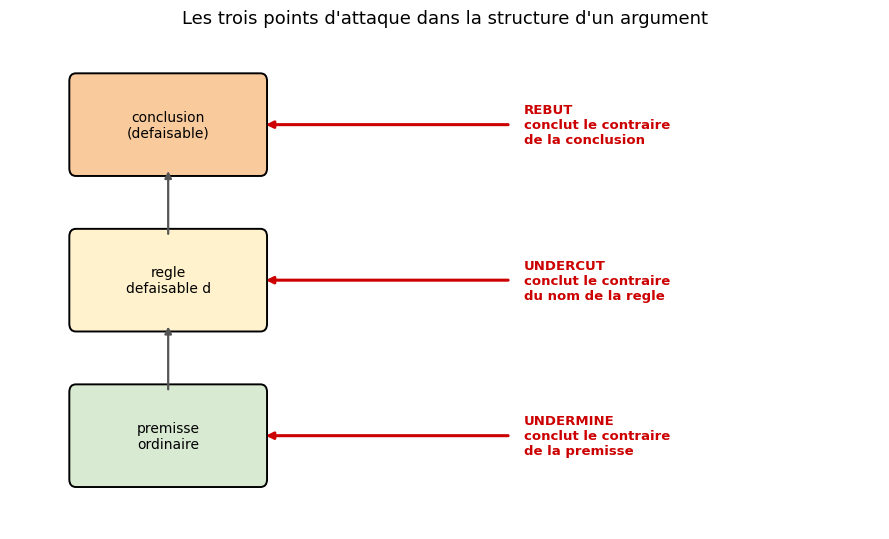

In [35]:
fig, ax = plt.subplots(figsize=(9, 5.5))
noeuds = {"concl": (0, 2), "regle": (0, 1), "prem": (0, 0)}
labels = {"concl": "conclusion\n(defaisable)", "regle": "regle\ndefaisable d", "prem": "premisse\nordinaire"}
cols = {"concl": "#f9cb9c", "regle": "#fff2cc", "prem": "#d9ead3"}
for k, (x, y) in noeuds.items():
    ax.add_patch(FancyBboxPatch((x - 0.7, y - 0.28), 1.4, 0.56, boxstyle="round,pad=0.05",
                                edgecolor="black", facecolor=cols[k], linewidth=1.4))
    ax.text(x, y, labels[k], ha="center", va="center", fontsize=10)
ax.annotate("", xy=(0, 0.72), xytext=(0, 0.28), arrowprops=dict(arrowstyle="-|>", lw=1.6, color="#555"))
ax.annotate("", xy=(0, 1.72), xytext=(0, 1.28), arrowprops=dict(arrowstyle="-|>", lw=1.6, color="#555"))

attaques_schema = [("REBUT\nconclut le contraire\nde la conclusion", 2, "#cc0000"),
                   ("UNDERCUT\nconclut le contraire\ndu nom de la regle", 1, "#cc0000"),
                   ("UNDERMINE\nconclut le contraire\nde la premisse", 0, "#cc0000")]
for txt, y, col in attaques_schema:
    ax.annotate("", xy=(0.72, y), xytext=(2.6, y),
                arrowprops=dict(arrowstyle="-|>", lw=2.2, color=col))
    ax.text(2.7, y, txt, ha="left", va="center", fontsize=9.5, color=col, fontweight="bold")
ax.set_xlim(-1.2, 5.4); ax.set_ylim(-0.6, 2.6); ax.axis("off")
ax.set_title("Les trois points d'attaque dans la structure d'un argument", fontsize=13)
plt.tight_layout(); plt.show()

### 2.2 Identification des points d'attaque

On parcourt la structure de l'argument cible et on renvoie, pour chaque point, le type d'attaque
et la formule qu'un contre-argument devrait conclure.


In [36]:
def points_attaque(arg):
    points = []
    for premisse in arg.getOrdinaryPremises():
        points.append(("undermine", "premisse " + str(premisse.getConclusion()),
                       contraire(premisse.getConclusion())))
    for sous in arg.getDefeasibleSubs():
        points.append(("rebut", "conclusion " + str(sous.getConclusion()),
                       contraire(sous.getConclusion())))
    for regle in arg.getDefeasibleRules():
        points.append(("undercut", "regle " + str(regle.getName()),
                       contraire(gen.getRuleFormula(regle))))
    return points

cible = None
for a in arguments:
    top = a.getTopRule()
    if meme(a.getConclusion(), f("coupable")) and top is not None and str(top.getName()) == "d1":
        cible = a

print("Argument cible :", idof(cible), "=", cible)
print("(coupable, deduit du temoignage par d1)\n")
for typ, ou, besoin in points_attaque(cible):
    print("  - %-10s sur %-20s -> un contre-argument doit conclure : %s" % (typ, ou, besoin))

Argument cible : A7 = d1: t => coupable [ => t]
(coupable, deduit du temoignage par d1)

  - undermine  sur premisse t           -> un contre-argument doit conclure : !t
  - rebut      sur conclusion coupable  -> un contre-argument doit conclure : !coupable
  - undercut   sur regle d1             -> un contre-argument doit conclure : !d1


### 2.3 Génération et classification des contre-arguments

On classe une attaque B -> A selon le point qu'elle vise, avec la précédence
`undercut > rebut > undermine`.


In [37]:
def type_attaque(attaquant, cible):
    c = attaquant.getConclusion()
    for regle in cible.getDefeasibleRules():
        if meme(c, contraire(gen.getRuleFormula(regle))):
            return "undercut"
    for sous in cible.getDefeasibleSubs():
        if meme(c, contraire(sous.getConclusion())):
            return "rebut"
    for premisse in cible.getOrdinaryPremises():
        if meme(c, contraire(premisse.getConclusion())):
            return "undermine"
    return None

dung = theorie.asDungTheory()

contre = {"undermine": [], "rebut": [], "undercut": []}
for att in dung.getAttacks():
    if str(att.getAttacked()) == str(cible):
        b = par_nom[str(att.getAttacker())]
        contre[type_attaque(b, cible)].append(b)

print("Contre-arguments generes contre", idof(cible), "(coupable via d1) :\n")
for typ in ["undermine", "rebut", "undercut"]:
    print("  [%s]" % typ.upper())
    for b in contre[typ]:
        print("     %-4s : %s   (conclut %s)" % (idof(b), b, b.getConclusion()))

Contre-arguments generes contre A7 (coupable via d1) :

  [UNDERMINE]
     A9   : d3: m => !t [ => m]   (conclut !t)
  [REBUT]
     A10  : d4: a => !coupable [ => a]   (conclut !coupable)
  [UNDERCUT]
     A11  : d5: pr => !d1 [ => pr]   (conclut !d1)


Les 3 contre-arguments attendus sont bien générés automatiquement pour la cible
« coupable via `d1` » :

- **undermine** : `m => ¬t` attaque la présomption `t` ;
- **rebut** : `a => ¬coupable` contredit la conclusion `coupable` ;
- **undercut** : `pr => ¬d1` invalide l'application de la règle `d1`.


### 2.4 Outillage de visualisation et classification globale

On fixe une disposition du graphe (réutilisée partout pour garder la même forme), on étiquette
chaque attaque du framework par son type, puis on affiche le graphe complet.


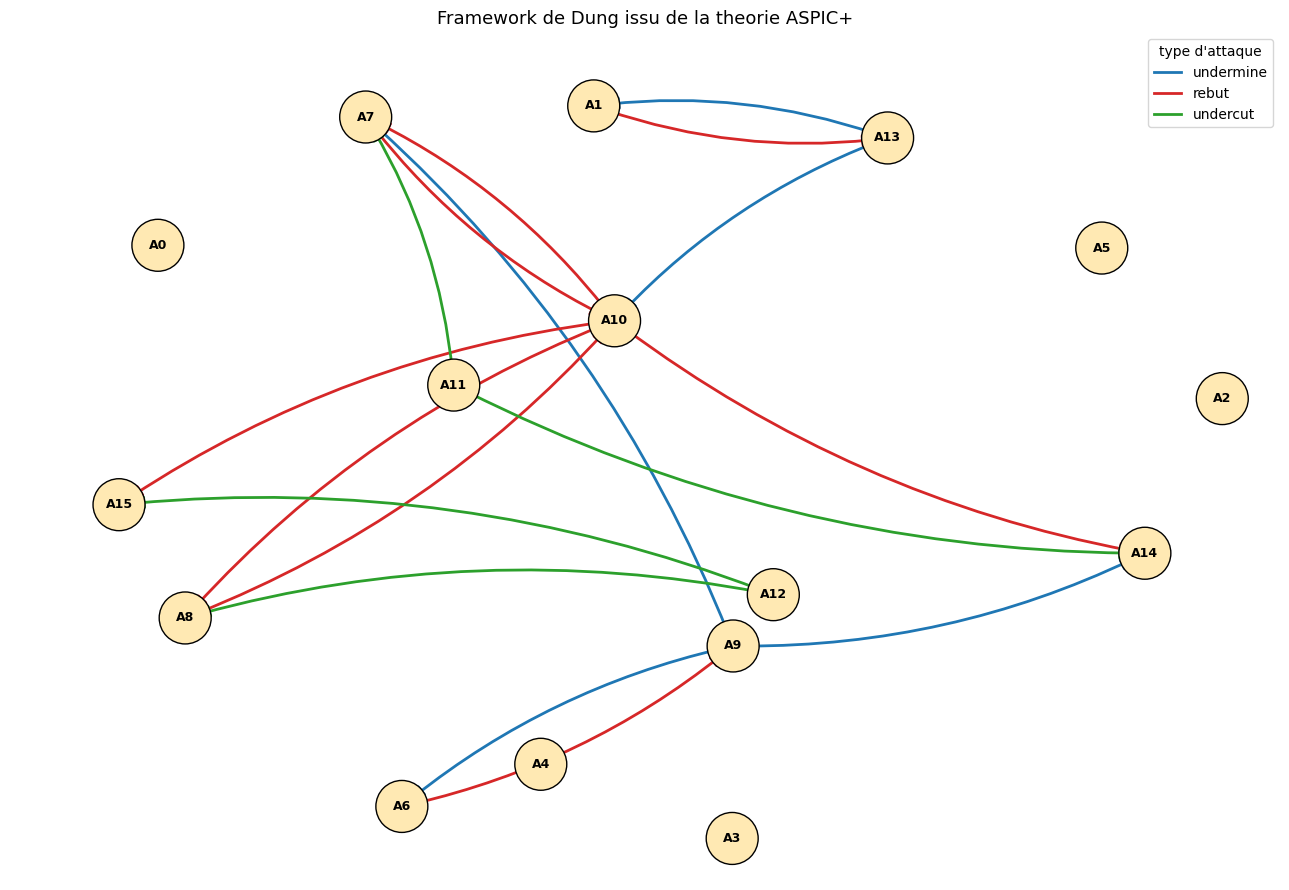

Legende des arguments :
  A0   =  -> adn
  A1   =  => a
  A2   =  => cam
  A3   =  => labo
  A4   =  => m
  A5   =  => pr
  A6   =  => t
  A7   = d1: t => coupable [ => t]
  A8   = d2: adn => coupable [ -> adn]
  A9   = d3: m => !t [ => m]
  A10  = d4: a => !coupable [ => a]
  A11  = d5: pr => !d1 [ => pr]
  A12  = d6: labo => !d2 [ => labo]
  A13  = d7: cam => !a [ => cam]
  A14  = s1: coupable -> punissable [d1: t => coupable [ => t]]
  A15  = s1: coupable -> punissable [d2: adn => coupable [ -> adn]]


In [38]:
attaques = []
for att in dung.getAttacks():
    b = par_nom[str(att.getAttacker())]
    a = par_nom[str(att.getAttacked())]
    attaques.append((b, a, type_attaque(b, a)))

ATT = [(idof(b), idof(a)) for (b, a, _) in attaques]
COUL_ATT = {"undermine": "tab:blue", "rebut": "tab:red", "undercut": "tab:green"}

GBASE = nx.DiGraph()
for a in arguments:
    GBASE.add_node(idof(a))
for (b, a, _) in attaques:
    GBASE.add_edge(idof(b), idof(a))
POS = nx.spring_layout(GBASE, seed=7, k=1.6)

def dessiner_graphe(couleur=None, titre="Framework d'argumentation", ax=None, legende="attaques"):
    seul = ax is None
    if seul:
        fig, ax = plt.subplots(figsize=(13, 9))
    couleur = couleur or {}
    cols = [couleur.get(idof(a), "#ffe9b3") for a in arguments]
    nx.draw_networkx_nodes(GBASE, POS, nodelist=[idof(a) for a in arguments],
                           node_color=cols, node_size=1400, edgecolors="black", ax=ax)
    nx.draw_networkx_labels(GBASE, POS, font_size=9, font_weight="bold", ax=ax)
    for typ, c in COUL_ATT.items():
        E = [(idof(b), idof(a)) for (b, a, t) in attaques if t == typ]
        nx.draw_networkx_edges(GBASE, POS, edgelist=E, edge_color=c, width=2,
                               arrowsize=18, connectionstyle="arc3,rad=0.12", ax=ax)
    if legende == "attaques":
        h = [plt.Line2D([0], [0], color=c, lw=2, label=t) for t, c in COUL_ATT.items()]
        ax.legend(handles=h, loc="upper right", fontsize=10, title="type d'attaque")
    elif legende == "statuts":
        h = [mpatches.Patch(color="#7fc97f", label="IN (accepte)"),
             mpatches.Patch(color="#e8736a", label="OUT (rejete)"),
             mpatches.Patch(color="#cfcfcf", label="UNDEC (indecis)")]
        ax.legend(handles=h, loc="upper right", fontsize=10, title="statut")
    ax.set_title(titre, fontsize=13); ax.axis("off")
    if seul:
        plt.tight_layout(); plt.show()

dessiner_graphe(titre="Framework de Dung issu de la theorie ASPIC+")
print("Legende des arguments :")
for a in arguments:
    print("  %-4s = %s" % (idof(a), a))

In [39]:
table = pd.DataFrame(
    [(idof(b), str(b.getConclusion()), idof(a), str(a.getConclusion()), typ)
     for (b, a, typ) in attaques],
    columns=["attaquant", "conclut", "cible", "conclut(cible)", "type"]
).sort_values(["type", "attaquant"]).reset_index(drop=True)
print("Nombre total d'attaques :", len(attaques), "\n")
print(table.to_string(index=False))
print("\nRepartition par type :")
print(table["type"].value_counts().to_string())

Nombre total d'attaques : 17 

attaquant   conclut cible conclut(cible)      type
       A1         a   A13             !a     rebut
      A10 !coupable   A14     punissable     rebut
      A10 !coupable   A15     punissable     rebut
      A10 !coupable    A7       coupable     rebut
      A10 !coupable    A8       coupable     rebut
       A6         t    A9             !t     rebut
       A7  coupable   A10      !coupable     rebut
       A8  coupable   A10      !coupable     rebut
      A11       !d1    A7       coupable  undercut
      A11       !d1   A14     punissable  undercut
      A12       !d2   A15     punissable  undercut
      A12       !d2    A8       coupable  undercut
      A13        !a   A10      !coupable undermine
      A13        !a    A1              a undermine
       A9        !t    A7       coupable undermine
       A9        !t    A6              t undermine
       A9        !t   A14     punissable undermine

Repartition par type :
type
rebut        8
undermi

### 2.5  **Démo Live** — explorateur de contre-arguments

On choisit un argument cible : ses contre-arguments sont listés par type et mis en évidence
sur le graphe (cible en orange, attaquants colorés selon le type d'attaque).

Quelques cibles : 
- `coupable` via `d1` (les 3 types)
- `coupable` via `d2` (rebut + undercut, mais pas d'undermine car fondé sur l'axiome `adn`)
- `¬coupable` (rebut + undermine de l'alibi).


Cible A7 : d1: t => coupable [ => t]

  undermine  : A9
  rebut      : A10
  undercut   : A11

  -> 3 contre-argument(s) genere(s).


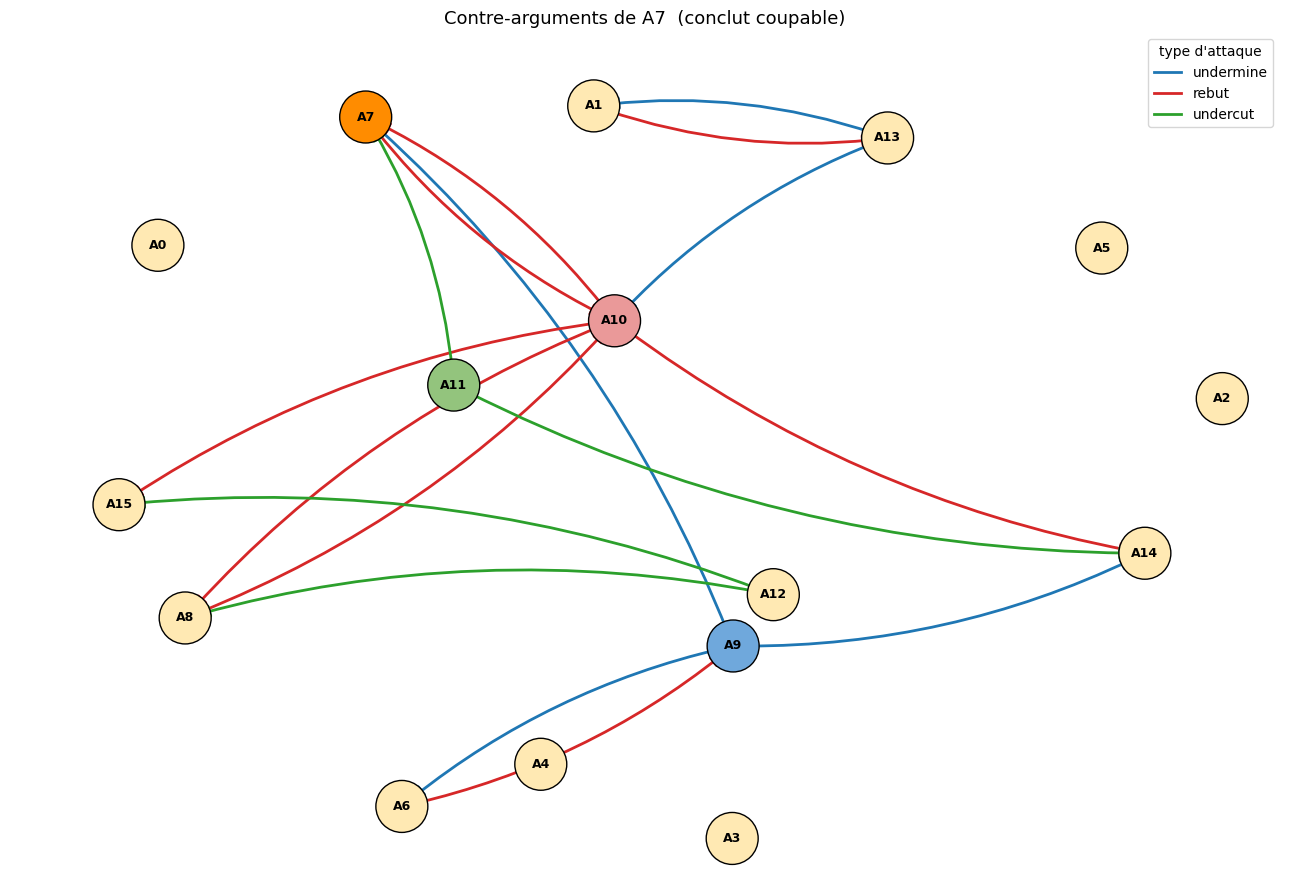

In [40]:
COUL_NOEUD = {"undermine": "#6fa8dc", "rebut": "#ea9999", "undercut": "#93c47d"}

def explorer_cible(argument):
    c = arg_par_id[argument]
    couleur = {argument: "#ff8c00"}
    info = {"undermine": [], "rebut": [], "undercut": []}
    for (b, a, t) in attaques:
        if str(a) == str(c) and t is not None:
            couleur[idof(b)] = COUL_NOEUD[t]
            info[t].append(b)
    print("Cible %s : %s\n" % (argument, c))
    total = 0
    for t in ["undermine", "rebut", "undercut"]:
        noms = [idof(b) for b in info[t]] or ["(aucun)"]
        print("  %-10s : %s" % (t, ", ".join(noms)))
        total += len(info[t])
    print("\n  -> %d contre-argument(s) genere(s)." % total)
    dessiner_graphe(couleur, "Contre-arguments de %s  (conclut %s)" % (argument, c.getConclusion()))

explorer_cible(idof(cible))

In [ ]:
interact(explorer_cible,
         argument=Dropdown(options=[idof(a) for a in arguments],
                           value=idof(cible), description="Cible"));

interactive(children=(Dropdown(description='Cible', index=7, options=('A0', 'A1', 'A2', 'A3', 'A4', 'A5', 'A6'…

## 3. Framework de Dung et sémantiques

### 3.1 Le framework abstrait obtenu

Chaque argument structuré devient un nœud, chaque contre-argument une arête. On raisonne alors
abstraitement « à la Dung ».


In [42]:
print("Framework de Dung :")
print("  arguments :", dung.getNumberOfNodes())
print("  attaques  :", len(dung.getAttacks()))

Framework de Dung :
  arguments : 16
  attaques  : 17


### 3.2 Les quatre sémantiques

Sur un ensemble E admissible (sans conflit et qui défend chacun de ses membres) :

- **grounded** : la plus petite extension complète, raisonnement sceptique, unique 
- **complete** : tout argument défendu par E est dans E 
- **preferred** : extension admissible maximale (inclusion) 
- **stable** : sans conflit et attaque tout argument extérieur


In [55]:
reasoners = {
    "grounded":  SimpleGroundedReasoner(),
    "complete":  SimpleCompleteReasoner(),
    "preferred": SimplePreferredReasoner(),
    "stable":    SimpleStableReasoner(),
}
sems = ["grounded", "complete", "preferred", "stable"]

def noms(extension):
    return set(str(x) for x in extension)

extensions = {nom: [noms(e) for e in r.getModels(dung)] for nom, r in reasoners.items()}

for nom in sems:
    exts = extensions[nom]
    print("=== %s : %d extension(s) ===" % (nom.upper(), len(exts)))
    for E in exts:
        courts = sorted(ids[n] for n in E)
        concl = sorted(set(str(par_nom[n].getConclusion()) for n in E))
        print("   {%s}" % ", ".join(courts))
        print("       conclusions :", ", ".join(concl))
    print()

=== GROUNDED : 1 extension(s) ===
   {A0, A11, A12, A2, A3, A4, A5}
       conclusions : !d1, !d2, adn, cam, labo, m, pr

=== COMPLETE : 9 extension(s) ===
   {A0, A11, A12, A13, A2, A3, A4, A5}
       conclusions : !a, !d1, !d2, adn, cam, labo, m, pr
   {A0, A1, A10, A11, A12, A2, A3, A4, A5, A6}
       conclusions : !coupable, !d1, !d2, a, adn, cam, labo, m, pr, t
   {A0, A11, A12, A2, A3, A4, A5}
       conclusions : !d1, !d2, adn, cam, labo, m, pr
   {A0, A11, A12, A13, A2, A3, A4, A5, A9}
       conclusions : !a, !d1, !d2, !t, adn, cam, labo, m, pr
   {A0, A11, A12, A2, A3, A4, A5, A9}
       conclusions : !d1, !d2, !t, adn, cam, labo, m, pr
   {A0, A11, A12, A13, A2, A3, A4, A5, A6}
       conclusions : !a, !d1, !d2, adn, cam, labo, m, pr, t
   {A0, A1, A10, A11, A12, A2, A3, A4, A5}
       conclusions : !coupable, !d1, !d2, a, adn, cam, labo, m, pr
   {A0, A1, A10, A11, A12, A2, A3, A4, A5, A9}
       conclusions : !coupable, !d1, !d2, !t, a, adn, cam, labo, m, pr
   {A0, A11, A

### 3.3 Étiquetage IN / OUT / UNDEC

Pour une extension E, un argument est:
- `IN` s'il est dans E
- `OUT` s'il est attaqué par un membre de E 
- `UNDEC` sinon

On colore le graphe selon cet étiquetage (ici l'extension
grounded).


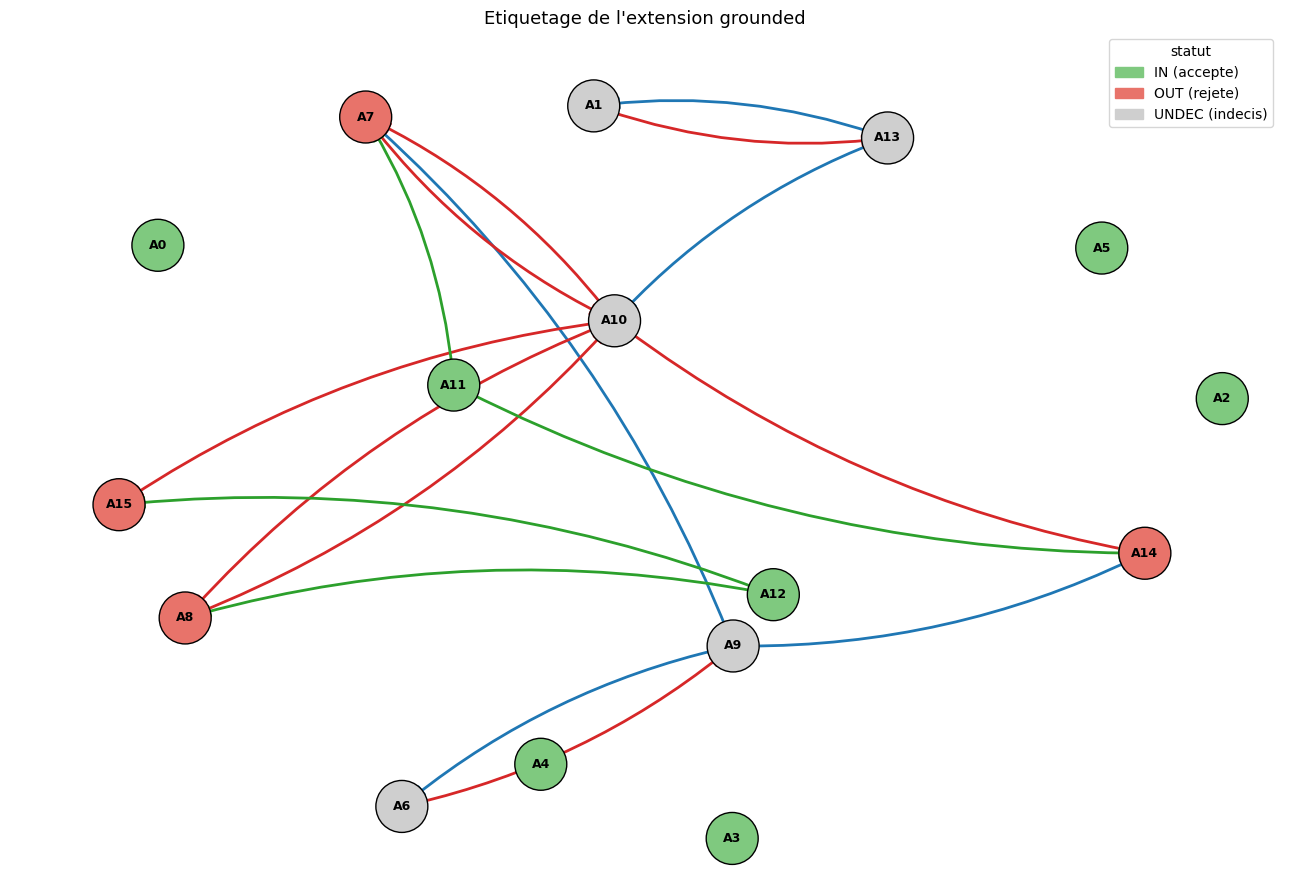

In [44]:
def labelling(E):
    membres = {ids[x] for x in E}
    statut = {}
    for a in arguments:
        n = idof(a)
        if n in membres:
            statut[n] = "IN"
        else:
            attaque = any(bb in membres and aa == n for (bb, aa) in ATT)
            statut[n] = "OUT" if attaque else "UNDEC"
    return statut

def couleur_extension(E):
    m = {"IN": "#7fc97f", "OUT": "#e8736a", "UNDEC": "#cfcfcf"}
    return {n: m[s] for n, s in labelling(E).items()}

E0 = extensions["grounded"][0]
dessiner_graphe(couleur_extension(E0),
                "Etiquetage de l'extension grounded", legende="statuts")

### 3.4  **Démo Live** — explorateur de sémantiques

On choisit la sémantique et l'indice d'extension : le graphe se recolore (IN/OUT/UNDEC) et
les conclusions acceptées s'affichent


In [45]:
def explorer_semantique(semantique, extension):
    exts = extensions[semantique]
    if not exts:
        print("Aucune extension pour", semantique); return
    E = exts[extension % len(exts)]
    concl = sorted(set(str(par_nom[n].getConclusion()) for n in E)) or ["(vide)"]
    print("Semantique %s -- extension %d / %d" % (semantique, extension % len(exts) + 1, len(exts)))
    print("Arguments IN :", ", ".join(sorted(ids[n] for n in E)) or "(aucun)")
    print("Conclusions acceptees :", ", ".join(concl))
    dessiner_graphe(couleur_extension(E),
                    "%s -- extension %d/%d" % (semantique, extension % len(exts) + 1, len(exts)),
                    legende="statuts")

maxext = max(len(extensions[s]) for s in sems)
interact(explorer_semantique,
         semantique=Dropdown(options=sems, value="preferred", description="Semantique"),
         extension=IntSlider(min=0, max=maxext - 1, value=0, description="Extension"));

interactive(children=(Dropdown(description='Semantique', index=2, options=('grounded', 'complete', 'preferred'…

## 4. Défendabilité des positions 

Une conclusion est   `sceptiquement` acceptée si soutenue dans toutes les extensions,
 `crédulement` si dans au moins une,  `rejetée` sinon. On évalue ainsi les positions face
aux contre-arguments générés.


In [46]:
def support(formule):
    cible = f(formule)
    return {idof(a) for a in arguments if meme(a.getConclusion(), cible)}

def statut(sup, liste_ext):
    if not liste_ext:
        return "rejete"
    pres = [bool(sup & {ids[x] for x in E}) for E in liste_ext]
    if all(pres): return "sceptique"
    if any(pres): return "credule"
    return "rejete"

claims = ["coupable", "!coupable", "punissable", "t", "!t", "a", "!a", "!d1", "!d2", "adn"]
lignes = [[c] + [statut(support(c), extensions[s]) for s in sems] for c in claims]
defend = pd.DataFrame(lignes, columns=["claim"] + sems)
print(defend.to_string(index=False))

     claim  grounded  complete preferred    stable
  coupable    rejete    rejete    rejete    rejete
 !coupable    rejete   credule   credule   credule
punissable    rejete    rejete    rejete    rejete
         t    rejete   credule   credule   credule
        !t    rejete   credule   credule   credule
         a    rejete   credule   credule   credule
        !a    rejete   credule   credule   credule
       !d1 sceptique sceptique sceptique sceptique
       !d2 sceptique sceptique sceptique sceptique
       adn sceptique sceptique sceptique sceptique


### 4.1 Carte de défendabilité

Visualisation : **vert = sceptique** / **jaune = crédule** / **rouge = rejeté**


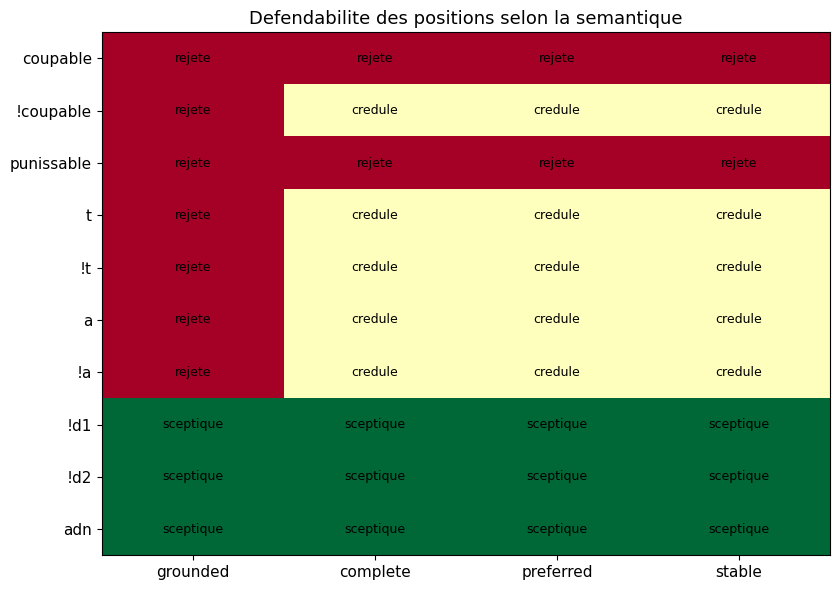

In [47]:
niveau = {"rejete": 0, "credule": 1, "sceptique": 2}
M = [[niveau[statut(support(c), extensions[s])] for s in sems] for c in claims]

fig, ax = plt.subplots(figsize=(8.5, 6))
im = ax.imshow(M, cmap="RdYlGn", vmin=0, vmax=2, aspect="auto")
ax.set_xticks(range(len(sems))); ax.set_xticklabels(sems, fontsize=11)
ax.set_yticks(range(len(claims))); ax.set_yticklabels(claims, fontsize=11)
for i in range(len(claims)):
    for j in range(len(sems)):
        nom = [k for k, v in niveau.items() if v == M[i][j]][0]
        ax.text(j, i, nom, ha="center", va="center", fontsize=9)
ax.set_title("Defendabilite des positions selon la semantique", fontsize=13)
plt.tight_layout(); plt.show()

Lecture :

`adn`, `¬d1` et `¬d2` sont acceptés de façon  `sceptique` dans les quatre sémantiques, ce sont les positions les plus solides du graphe : leurs undercuts ne sont jamais contredits.

Le plus intéressant : `coupable` est  `rejeté partout `. Les deux seules façons d'y arriver (via `d1`, le témoignage, ou via `d2`, l'ADN) sont chacune coupées par un undercut lui-même jamais attaqué (`¬d1` et `¬d2`). C'est l'undercut qui fait basculer le résultat.

`¬coupable`, `t`, `a`... restent seulement  `crédules` : ce sont des conflits symétriques (rebut ou undermine, comme `a` contre `¬a`) que preferred et stable tranchent chacune à leur façon, sans qu'aucune sémantique ne les accepte de manière sceptique.

**Bilan** : avec les contre-arguments générés, « le suspect est coupable » n'est plus défendable, alors qu'avant le doute sur le labo la voie de l'ADN restait ouverte. C'est exactement ce que l'analyse de défendabilité devait montrer.


### 4.2  **Démo Live** — défendabilité d'une position

On choisit une conclusion : son statut sous chaque sémantique s'affiche.


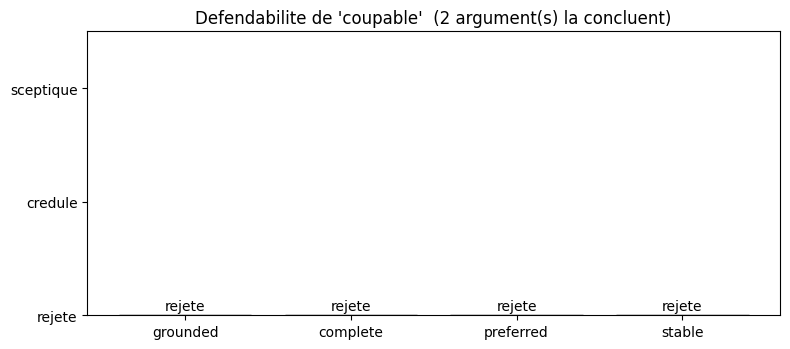

In [ ]:
def explorer_claim(claim):
    sup = support(claim)
    vals = [niveau[statut(sup, extensions[s])] for s in sems]
    coul = {0: "#e8736a", 1: "#ffd966", 2: "#7fc97f"}
    fig, ax = plt.subplots(figsize=(8, 3.6))
    barres = ax.bar(sems, vals, color=[coul[v] for v in vals], edgecolor="black")
    for b, v in zip(barres, vals):
        nom = [k for k, n in niveau.items() if n == v][0]
        ax.text(b.get_x() + b.get_width() / 2, v + 0.05, nom, ha="center", fontsize=10)
    ax.set_ylim(0, 2.5); ax.set_yticks([0, 1, 2])
    ax.set_yticklabels(["rejete", "credule", "sceptique"])
    ax.set_title("Defendabilite de '%s'  (%d argument(s) la concluent)" % (claim, len(sup)), fontsize=12)
    plt.tight_layout(); plt.show()

explorer_claim("coupable")

In [49]:
interact(explorer_claim,
         claim=Dropdown(options=claims, value="coupable", description="Conclusion"));

interactive(children=(Dropdown(description='Conclusion', options=('coupable', '!coupable', 'punissable', 't', …

## 5. Comparaison ASPIC+ VS frameworks abstraits 

Un framework abstrait de Dung se donne directement comme des arguments « boîtes noires » et une
relation d'attaque primitive. On modélise le même scénario en abstrait, en devant poser les
attaques à la main, puis on compare les deux graphes côte à côte.


In [50]:
abstrait = DungTheory()
noeuds = {}
for n in ["Coup_temoin", "Coup_adn", "NonT", "NonCoup", "NonD1", "NonD2", "NonA"]:
    x = Argument(n); noeuds[n] = x; abstrait.add(x)

paires = [("NonT", "Coup_temoin"), ("Coup_temoin", "NonT"), ("NonD1", "Coup_temoin"),
          ("NonCoup", "Coup_temoin"), ("Coup_temoin", "NonCoup"),
          ("NonCoup", "Coup_adn"), ("Coup_adn", "NonCoup"),
          ("NonD2", "Coup_adn"), ("NonA", "NonCoup")]
for u, v in paires:
    abstrait.addAttack(noeuds[u], noeuds[v])

print("AF abstrait :", abstrait.getNumberOfNodes(), "arguments,",
      len(abstrait.getAttacks()), "attaques posees manuellement\n")
for nom, r in reasoners.items():
    exts = [sorted(str(x) for x in e) for e in r.getModels(abstrait)]
    print("%-9s : %d extension(s)" % (nom, len(exts)))

AF abstrait : 7 arguments, 9 attaques posees manuellement

grounded  : 1 extension(s)
complete  : 1 extension(s)
preferred : 1 extension(s)
stable    : 1 extension(s)


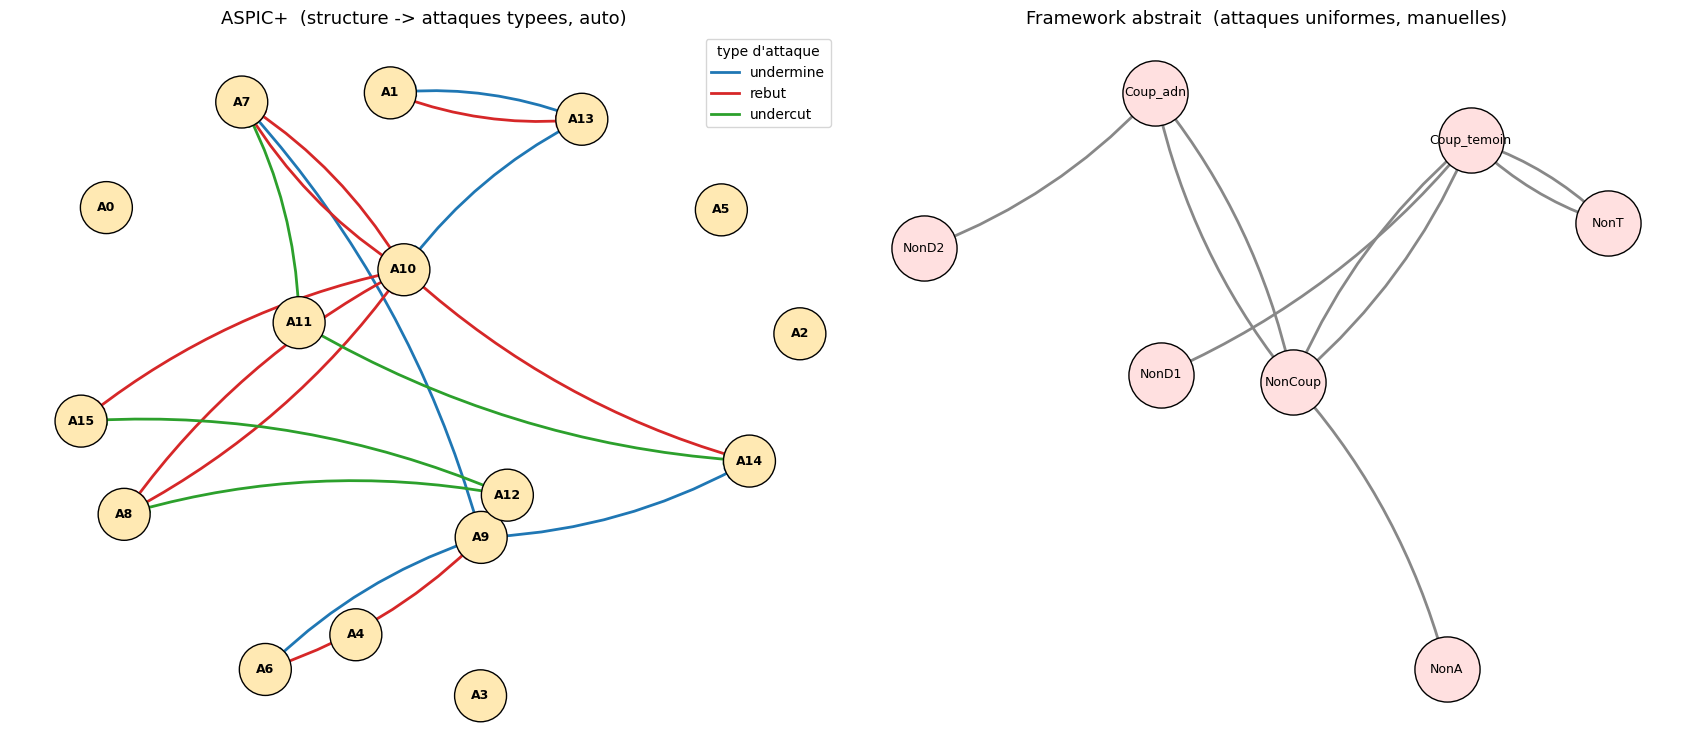

In [51]:
Gabs = nx.DiGraph()
for n in noeuds: Gabs.add_node(n)
for u, v in paires: Gabs.add_edge(u, v)
posabs = nx.spring_layout(Gabs, seed=3, k=1.5)

fig, axes = plt.subplots(1, 2, figsize=(17, 7.5))
dessiner_graphe(titre="ASPIC+  (structure -> attaques typees, auto)", ax=axes[0])
nx.draw_networkx_nodes(Gabs, posabs, node_color="#ffe0e0", node_size=2200,
                       edgecolors="black", ax=axes[1])
nx.draw_networkx_labels(Gabs, posabs, font_size=9, ax=axes[1])
nx.draw_networkx_edges(Gabs, posabs, edge_color="#888", width=2, arrowsize=20,
                       connectionstyle="arc3,rad=0.12", ax=axes[1])
axes[1].set_title("Framework abstrait  (attaques uniformes, manuelles)", fontsize=13)
axes[1].axis("off")
plt.tight_layout(); plt.show()

### 5.1 Synthèse de la richesse


In [52]:
comparaison = pd.DataFrame([
    ["Structure interne des arguments", "Oui (premisses + regles)", "Non (boites noires)"],
    ["Distinction axiome / presomption", "Oui", "Non"],
    ["Distinction regle stricte / defaisable", "Oui", "Non"],
    ["Generation auto des attaques", "Oui (depuis la structure)", "Non (a poser a la main)"],
    ["Typage undercut / rebut / undermine", "Oui", "Non"],
    ["Ordre de preference sur arguments", "Oui", "Non (au niveau du FW)"],
    ["Calcul des extensions de Dung", "Oui", "Oui"],
], columns=["Critere", "ASPIC+", "Framework abstrait"])
print(comparaison.to_string(index=False))

                               Critere                    ASPIC+      Framework abstrait
       Structure interne des arguments  Oui (premisses + regles)     Non (boites noires)
      Distinction axiome / presomption                       Oui                     Non
Distinction regle stricte / defaisable                       Oui                     Non
          Generation auto des attaques Oui (depuis la structure) Non (a poser a la main)
   Typage undercut / rebut / undermine                       Oui                     Non
     Ordre de preference sur arguments                       Oui   Non (au niveau du FW)
         Calcul des extensions de Dung                       Oui                     Oui


**Conclusion:** 

Le framework abstrait calcule bien des extensions, mais il suppose les attaques données. ASPIC+ est strictement plus riche : à partir de la seule base de connaissances et des
règles, il engendre arguments et attaques, distingue les trois types de contre-arguments et
permet d'exprimer des préférences. Cette granularité est indispensable pour générer
automatiquement des contre-arguments, là où le formalisme abstrait ne peut que les évaluer.


## 6. Bilan — objectifs validés

| # | Objectif | Où | Statut |
|---|---|---|---|
| 1 | Formaliser en ASPIC+ (strictes/défaisables, axiomes/présomptions) | §1 | ✅ |
| 2 | Générer automatiquement undercut / rebut / undermine | §2 | ✅ |
| 3 | Calculer les extensions (grounded, complete, preferred, stable) | §3 | ✅ |
| 4 | Évaluer la défendabilité des positions | §4 | ✅ |
| 5 | Comparer ASPIC+ vs frameworks abstraits | §5 | ✅ |

L'implémentation via TweetyProject garantit la correction formelle : construction des
arguments, calcul des attaques et sémantiques de Dung sont assurés par la bibliothèque, tandis que
notre code identifie les points d'attaque, classe les contre-arguments et pilote les visualisations.
